In [ ]:
from google.colab import files

# This will open a file picker dialog
uploaded = files.upload()

Saving names.txt to names.txt


In [ ]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
len(words)

32033

In [ ]:
min(len(w) for w in words)

2

In [ ]:
max(len(w) for w in words)

15

In [ ]:
b = {}  # Dictionary
for w in words:
  chars = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chars, chars[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1  # Key value pair

In [ ]:
# b.items returns the dict tuples as kv where kv[0] is key
# Minus make the count negative (-6763)
sorted(b.items(), key=lambda kv: -kv[1])  # Sorting by value descending

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
import torch

In [ ]:
a = torch.zeros(3, 5)  # Default is float32
a[0, 0] = 1
a

tensor([[1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [ ]:
N = torch.zeros((27, 27), dtype=torch.int32)  # Not 28 cuz <S> = <E> = .

In [ ]:
chars = sorted(list(set(''.join(words))))   # Separate('') by empty/no space
stoi = {s:i+1 for i, s in enumerate(chars)}  # Lookup dict
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}  # Now, we can interchange both easily
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [ ]:
# Dataset creation

for w in words:
  chars = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chars, chars[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1  # Saving in 2D tensor for training

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

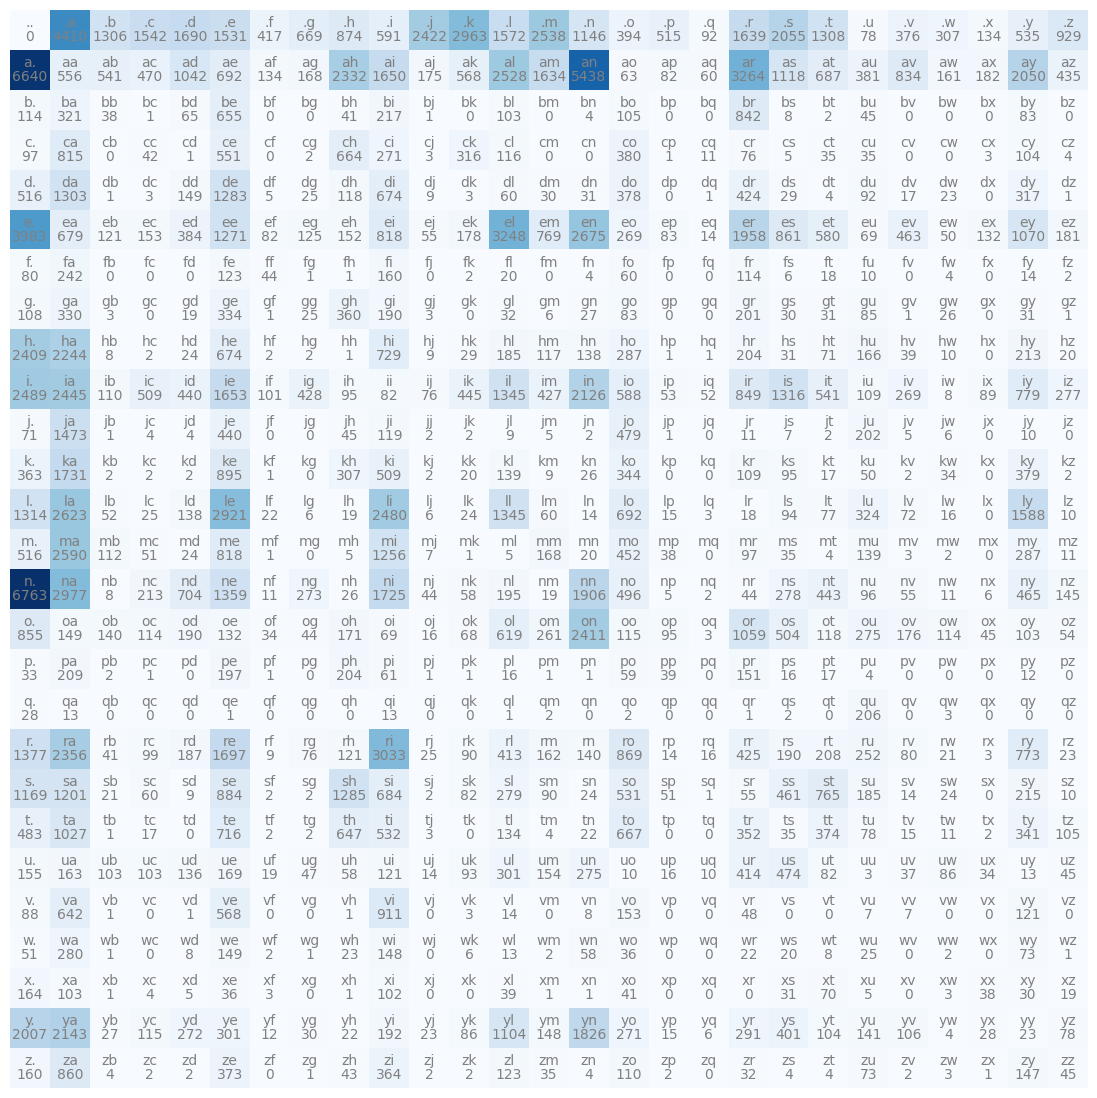

In [ ]:
plt.figure(figsize=(14, 14))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    bigram = itos[i] + itos[j]
    # Horizontal, Vertical
    plt.text(j, i, bigram, ha='center', va='bottom', color='gray')
    plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off');  # Turns off the <text> above plot

In [ ]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()  # Normalize
p

tensor([0.6064, 0.3033, 0.0903])

In [ ]:
# replacement = True can pick same index multiple times
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [ ]:
p = N[0].float()  # First row
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [ ]:
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]  # Generated a char at random using 1st row prob distribution

'f'

In [ ]:
# P.sum(0, keepdim=True)  # Summing each column row-wise --> Row vector
# keepdim=True don't squeezes the size 1 dimensions
# P.sum(1, keepdim=True)  # Summing each row column-wise --> Column vector

In [ ]:
# Smoothing model by adding 1 because log(0) = -inf.
P = (N + 1).float()         # (27, 27) Both are aligned
P /= P.sum(1, keepdim=True) # (27, 1) Broadcasting can be done

In [ ]:
# Sampling
g = torch.Generator().manual_seed(2147483647)  # Reseed to reset everytime

for i in range(10):
  out = []
  ix = 0  # Starting character(.)
  while True:
    p = N[ix].float()
    p = p / p.sum()
    # Reassigning that ix's char row for next char probability
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:  # Till end character(.)
      break
  print(''.join(out))  # Printing after each loop

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [ ]:
1/27.0  # If the characters are equally distributed

0.037037037037037035

In [ ]:
# Evaluation
log_likelihood = 0.0  # Quality of model; Should be close to zero
n = 0

for w in words:
  chars = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chars, chars[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]  # Likelihood = Product of probabilities
    logprob = torch.log(prob)  # Summation is easy than product
    log_likelihood += logprob  # Log likelihood = Sum of log(probs)
    n += 1
    # print(f"{ch1}{ch2}: {prob: .4f} {logprob: .4f}")

print(log_likelihood)
nll = -log_likelihood  # Negative log likelihood
print(nll/n)  # Normalized loss function

tensor(-559951.5625)
tensor(2.4544)


# Neural Net

In [ ]:
# Dataset creation

xs, ys = [], []  # Feature, Target

for w in words:
  chars = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chars, chars[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    # print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)  # Use tensor for auto dtype
ys = torch.tensor(ys)  # Not Tensor for default float32
num = xs.nelement()
print("Number of bigrams: ", num)

Number of bigrams:  228146


In [ ]:
# Initializing weights

# Draws probabilities from standard normal distribution (-3, -2, -1, 0, 1, 2, 3)
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27, 27), generator=g, requires_grad=True)

In [ ]:
# One hot encoding makes len(xs) zero vectors with num_classes dimensions
# Except xs[] positions turned on to 1
import torch.nn.functional as F
x_enc = F.one_hot(xs, num_classes=27).float()  # Casted to float32 cuz xs is int32
x_enc.shape

torch.Size([228146, 27])

In [ ]:
# Gradient descent

for k in range(100):

  # Forward pass
  logits = x_enc @ w  # Matrix multiplication giving us log counts
  counts = logits.exp()  # To make logits positive, equivalent to N
  probs = counts / counts.sum(1, keepdim=True)
  # The last 2 lines are called softmax
  # Loss + Regularization
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(w**2).mean()
  print(loss.item())

  # Backward pass
  w.grad = None  # Zero gradient
  loss.backward()

  # Update
  w.data += -50 * w.grad

3.7686190605163574
3.3788065910339355
3.16109037399292
3.0271859169006348
2.9344842433929443
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188303470611572
2.696505546569824
2.6773719787597656
2.6608052253723145
2.6463515758514404
2.633664846420288
2.622471570968628
2.6125476360321045
2.6037068367004395
2.595794916152954
2.5886809825897217
2.5822560787200928
2.5764293670654297
2.5711236000061035
2.5662729740142822
2.5618228912353516
2.5577263832092285
2.5539441108703613
2.550442695617676
2.5471925735473633
2.5441696643829346
2.5413522720336914
2.538722038269043
2.536262035369873
2.5339581966400146
2.531797409057617
2.529768228530884
2.527859926223755
2.5260636806488037
2.5243701934814453
2.522773265838623
2.52126407623291
2.519836902618408
2.5184857845306396
2.5172054767608643
2.515990734100342
2.5148372650146484
2.5137407779693604
2.512697696685791
2.511704921722412
2.5107581615448
2.509854555130005
2.5089924335479736
2.5081682205200195
2.507380485534668


In [ ]:
probs.shape

torch.Size([228146, 27])

In [ ]:
nlls = torch.zeros(5)  # .emma.
for i in range(5):
  x = xs[i].item()
  y = ys[i].item()
  print('----------')
  print(f"Bigram {i+1}: {itos[x]}{itos[y]}: {x},{y}")
  print("Output probabilities for 2nd character in bigram:\n", probs[i])  # Weights
  p = probs[i, y]  # [0, 5], [1, 13], [2, 13], [3, 1], [4, 0]
  print("Probability assigned for correct next character: ", p.item())
  nll = -torch.log(p)
  print("nll: ", nll.item())
  nlls[i] = nll

print("\nAverage loss: ", nlls.mean())

----------
Bigram 1: .e: 0,5
Output probabilities for 2nd character in bigram:
 tensor([0.0016, 0.1373, 0.0406, 0.0479, 0.0525, 0.0476, 0.0131, 0.0209, 0.0272,
        0.0184, 0.0753, 0.0922, 0.0489, 0.0789, 0.0356, 0.0124, 0.0161, 0.0032,
        0.0510, 0.0639, 0.0407, 0.0031, 0.0118, 0.0097, 0.0045, 0.0167, 0.0289],
       grad_fn=<SelectBackward0>)
Probability assigned for correct next character:  0.04760393500328064
nll:  3.044839859008789
----------
Bigram 2: em: 5,13
Output probabilities for 2nd character in bigram:
 tensor([0.1942, 0.0330, 0.0063, 0.0077, 0.0187, 0.0618, 0.0044, 0.0065, 0.0075,
        0.0397, 0.0038, 0.0088, 0.1583, 0.0373, 0.1303, 0.0131, 0.0047, 0.0019,
        0.0953, 0.0418, 0.0282, 0.0042, 0.0225, 0.0025, 0.0066, 0.0520, 0.0090],
       grad_fn=<SelectBackward0>)
Probability assigned for correct next character:  0.037337757647037506
nll:  3.287750244140625
----------
Bigram 3: mm: 13,13
Output probabilities for 2nd character in bigram:
 tensor([0.0739, 0.

In [ ]:
# Sampling

g = torch.Generator().manual_seed(2147483647)  # Reseed to reset everytime

for i in range(10):
  out = []
  ix = 0  # Starting character(.)
  while True:
    x_enc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = x_enc @ w  # Matrix multiplication giving us log counts
    counts = logits.exp()  # To make logits positive, equivalent to N
    probs = counts / counts.sum(1, keepdim=True)
    # The last 2 lines are called softmax
    # Reassigning that ix's char row for next char probability
    ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:  # Till end character(.)
      break
  print(''.join(out))  # Printing after each loop

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [ ]:
probs.shape

torch.Size([1, 27])